# Getting a solution to a PDE with a PINN

##### Introduction
We will consider a 1 dimensional wave equation
$$u_{tt} = c^2 u_{xx}$$
with initial conditions:
$$u(x,0) = \sin(\pi x)$$
$$u_t(x,0) = 0$$
and boundary conditions
$$u(0,t) = u(1,t) = 0$$

We can verify that $u(x,t) = \sin(\pi x)\cos(\pi t)$ satisfies this equation with $c=1$

- $u_x(x,t) = \pi \cos(\pi x)\cos(\pi t)$
- $u_t(x,t) = -\pi \sin(\pi x)\sin(\pi t)$
- $u_{xx}(x,t) = -\pi^2 \sin(\pi x)\cos(\pi t)$
- $u_{tt}(x,t)= -\pi^2 \sin(\pi x)(\cos \pi t)$
This we can see that $u_{tt} = u_{xx}$ so the main equation is satisfies for $c=1$

$u(x,0) = \sin(\pi x) \cos (\pi \times 0) = \sin(\pi x)$

$u_t(x,0) = -\pi \sin(\pi x) \sin(\pi \times 0) = 0$

$u(0,t) = \sin(\pi \times 0) \cos(\pi t) = 0$

$u(1,t) = \sin (\pi \times 1) \cos(\pi t) = 0$

Thus all the conditions are satisfied.

In [1]:
# necessary imports
import torch
import matplotlib.pyplot as plt
import math
from pinn_utils.pinn import PINN, pde_solve, compute_unique_derivatives

#### Setting up the regions and equations to go into the PINN

In [2]:
# basic values used for this specific problem
c = 1
L = 1
T = 1
x_min, x_max = 0, L
t_min, t_max = 0, T

In [21]:
# create the network that will be used to train
NN = PINN(
    num_inputs = 2,   # 2 inputs x,t
    num_hidden_layers=4, # 4 hidden layers (with default width of 64)
    input_activation=torch.sin, # activation function is sin for input layer
    hidden_activation=torch.sin # activation function is sin for hidden layers
    )

In [22]:
# the DE itself
def wave_eq(NN, X, c=1.0):
    # compute the first and second order derivatives of NN 
    # here x0 is the first independent variable, x, and x1 is the 2nd independent variable, t.
    derivs = compute_unique_derivatives(lambda x: NN(x), X, order=2)[0]
    # return NN_tt - c**2 * NN_xx
    return derivs["x1_x1"] - c**2 * derivs["x0_x0"]

# the network can struggle on interior points so we take extra points near the center for our X_DE 
N_total = 5000  # total DE points
N_center = 1000  # points concentrated near the center
N_uniform = N_total - N_center

# 1. Uniform random points across the domain
X_uniform = torch.rand(N_uniform, 2)  # (x,t) in [0,1]x[0,1]

# 2. Points concentrated around the center
center = 0.5
spread = 0.15  # stddev of normal distribution around the center
X_center = torch.clamp(
    torch.normal(mean=center, std=spread, size=(N_center,2)),
    min=0.0, max=1.0
)
# 3 combine
X_DE = torch.cat([X_uniform, X_center], dim=0)

In [23]:
# now the initial conditions
# X_IC are points of the form (x,0)
# choose 500 x values at random in [0,L] (here L=1) and set the t coordinates to be 0
X_IC = torch.cat([torch.rand(500,1)*L, torch.zeros(500,1)], dim=1)
# analytic f and g
def f_ic(NN, X):
    # return shape (N,1)
    return NN(X) - torch.sin(math.pi * X[:, 0:1])

def g_ic(X):
    # in this case g(x)=0, but keep shape (N,1)
    return torch.zeros_like(X[:, 0:1])

# derivative-IC callable: returns du_dt - g(X) 
def ut_IC( u, X):
    # this takes an arbitrary function and set X and returns 
    # du/dt(X) - g_ic(X)
    derivs = compute_unique_derivatives(lambda x: u(x), X, order=1)[0]
    du_dt = derivs["x1"].unsqueeze(1)   # derivative w.r.t. t
    return du_dt - g_ic(X)        # return residual shape (N,1)
# create one specifically for the neural network
# out list of IC conditions
IC_list = [
    (X_IC, f_ic),   # u(x,0) = f(x)
    (X_IC, ut_IC)   # du/dt(x,0) - g(x)  (g is zero here)
]


In [ ]:
# now the boundary conditions. Since we just have u(0,t) = u(1,t) = 0 we won't assign functions but just sets
# the two sets 0 x [0,1] and 1 x [0,1]
X_BC0 = torch.cat([torch.zeros(500,1), torch.rand(500,1)], dim=1)
X_BC1 = torch.cat([torch.ones(500,1)*L, torch.rand(500,1)], dim=1)
# these both should have the function u evaluate to 0 on it
u_BC0 = lambda NN, X : NN(X)
u_BC1 = lambda NN, X : NN(X)
BC_list = [
    (X_BC0, u_BC0),  # u(0,t)=0
    (X_BC1, u_BC1)   # u(1,t)=0
]

#### Looking at the true solution

In [25]:
def true_solution(X):
    x, t = X[:,0], X[:,1]
    return (torch.sin(math.pi*x) * torch.cos(math.pi*t)).unsqueeze(-1) # c=1, one spatial period

# the wave equation using true_solution on X_DE should give us values of zero (there can be some floating point error)
u_DE = wave_eq(true_solution, X_DE.requires_grad_(True))

print(f"Max value : {u_DE.max().item()}")
print(f"Min value : {u_DE.min().item()}")
print(f"Mean absolute value : {u_DE.abs().mean()}")

Max value : 9.5367431640625e-07
Min value : -9.5367431640625e-07
Mean absolute value : 1.1439151137437875e-07


In [26]:
# for the initial value we should have true_solution(X_IC) = f_ic(X_IC) and
# true_solution_t(X_IC) = g_IC(X_IC)
true_ic_1 =f_ic(true_solution, X_IC)
true_ic_2 = ut_IC(true_solution, X_IC.requires_grad_(True))

In [27]:
print(f"Max value for true_ic_1 : {true_ic_1.max().item()}")
print(f"Min value for true_ic_1 : {true_ic_1.min().item()}")
print(f"Mean absolute value for true_ic_1 : {true_ic_1.abs().mean()}")
print(f"Max value for true_ic_2 : {true_ic_2.max().item()}")
print(f"Min value for true_ic_2 : {true_ic_2.min().item()}")
print(f"Mean absolute value for true_ic_2 : {true_ic_2.abs().mean()}")

Max value for true_ic_1 : 0.0
Min value for true_ic_1 : 0.0
Mean absolute value for true_ic_1 : 0.0
Max value for true_ic_2 : 0.0
Min value for true_ic_2 : 0.0
Mean absolute value for true_ic_2 : 0.0


In [28]:
# for the boundary conditions we should just have true_solution be 0 on X_BC0 and X_BC1
true_bc0 = u_BC0(true_solution, X_BC0)
true_bc1 = u_BC1(true_solution, X_BC1)
print(f"Max on X_BC0 : {true_bc0.max().item()}")
print(f"Min on X_BC0 : {true_bc0.min().item()}")
print(f"Mean absolute value on X_BC0 : {true_bc0.abs().mean()}")
print(f"Max on X_BC1 : {true_bc1.max().item()}")
print(f"Min on X_BC1 : {true_bc1.min().item()}")
print(f"Mean absolute value on X_BC0 : {true_bc1.abs().mean()}")

Max on X_BC0 : -0.0
Min on X_BC0 : -0.0
Mean absolute value on X_BC0 : 0.0
Max on X_BC1 : 8.742264867578342e-08
Min on X_BC1 : -8.742277657347586e-08
Mean absolute value on X_BC0 : 5.551972748207845e-08


We can see that up to some floating point error here, the true solution does satisfy the equation, initial conditions, and boundary conditions.

#### Training the model

In [29]:
# invoke the solver with the DE, X_DE, network, and ICs/BCs
solution = pde_solve(
    DE=wave_eq,
    X_DE=X_DE,
    NN=NN,
    IC_list=IC_list,
    BC_list=BC_list
)

Training:   0%|          | 0/5000 [00:00<?, ?epoch/s]

Training: 100%|██████████| 5000/5000 [12:17<00:00,  6.78epoch/s, loss=0.000127, val_loss=nan]


##### We can now test the solution the same way we looked at the true solution

In [30]:
# for the DE on the interior set
u_DE_NN = wave_eq(solution, X_DE.requires_grad_(True))

print(f"Max value : {u_DE_NN.max().item()}")
print(f"Min value : {u_DE_NN.min().item()}")
print(f"Mean absolute value : {u_DE_NN.abs().mean()}")

Max value : 0.030224069952964783
Min value : -0.024331659078598022
Mean absolute value : 0.007948799058794975


In [31]:
# for the initial value we should have solution(X_IC) = f_ic(X_IC) and
# solution_t(X_IC) = g_IC(X_IC)
solve_ic_1 = f_ic(solution, X_IC.clone().detach().requires_grad_(True))
solve_ic_2 = ut_IC(solution,X_IC.clone().detach().requires_grad_(True))
print(f"Max value for solve_ic_1 : {solve_ic_1.max().item()}")
print(f"Min value for solve_ic_1 : {solve_ic_1.min().item()}")
print(f"Mean absolute value for solve_ic_1 : {solve_ic_1.abs().mean()}")
print(f"Max value for solve_ic_2 : {solve_ic_2.max().item()}")
print(f"Min value for solve_ic_2 : {solve_ic_2.min().item()}")
print(f"Mean absolute value for solve_ic_2 : {solve_ic_2.abs().mean()}")

Max value for solve_ic_1 : 0.007059276103973389
Min value for solve_ic_1 : -0.0028795599937438965
Mean absolute value for solve_ic_1 : 0.0027531280647963285
Max value for solve_ic_2 : 0.01557353138923645
Min value for solve_ic_2 : -0.003138115629553795
Mean absolute value for solve_ic_2 : 0.0022382952738553286


In [34]:
solve_bc0 = solution(X_BC0)
solve_bc1 = solution(X_BC1)
print(f"Max on X_BC0 : {solve_bc0.max().item()}")
print(f"Min on X_BC0 : {solve_bc0.min().item()}")
print(f"Mean absolute value on X_BC0 : {solve_bc0.abs().mean()}")
print(f"Max on X_BC1 : {solve_bc1.max().item()}")
print(f"Min on X_BC1 : {solve_bc1.min().item()}")
print(f"Mean absolute value on X_BC0 : {solve_bc1.abs().mean()}")

Max on X_BC0 : 0.003481820225715637
Min on X_BC0 : -0.0008205100893974304
Mean absolute value on X_BC0 : 0.0010138903744518757
Max on X_BC1 : 0.003962874412536621
Min on X_BC1 : -0.0032930299639701843
Mean absolute value on X_BC0 : 0.002299694577232003


We can see that the solution does a reasonable job of satisfying the DE and initial conditions. we can try simply comparing the solution with the true solution on $[0,1]$

In [69]:

# Number of points along each axis
N = 500

# Create 1D tensors of coordinates
x = torch.linspace(0, 1, N)
y = torch.linspace(0, 1, N)

# Create a meshgrid
X, Y = torch.meshgrid(x, y, indexing='ij')  # 'ij' makes X vary along rows, Y along columns

# Stack and reshape into a list of 2D points
grid = torch.stack([X, Y], dim=-1).reshape(-1, 2)



In [66]:
u_true = true_solution(grid)
u_pred = solution(grid)
print(f"Maximum absolute error: {(u_true - u_pred).abs().max()}")
print(f"Mean absolute error : {(u_true-u_pred).abs().mean()}")
print(f"Root Mean Square Error: {math.sqrt(((u_true-u_pred)**2).mean())}")

Maximum absolute error: 0.01073676347732544
Mean absolute error : 0.003091901307925582
Root Mean Square Error: 0.003783328903795406


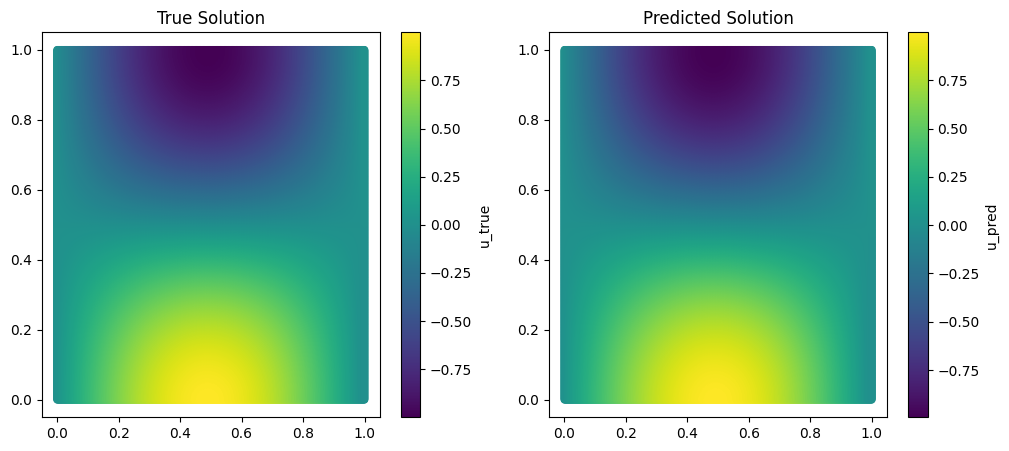

In [67]:

x, t = grid[:, 0], grid[:, 1]


# Convert to numpy for plotting
X_np = grid.detach().numpy()
u_pred_np = u_pred.detach().numpy().flatten()
u_true_np = u_true.numpy().flatten()

plt.figure(figsize=(12,5))

# True solution
plt.subplot(1,2,1)
plt.scatter(X_np[:,0], X_np[:,1], c=u_true_np, cmap='viridis', s=20)
plt.colorbar(label='u_true')
plt.title('True Solution')

# Predicted solution
plt.subplot(1,2,2)
plt.scatter(X_np[:,0], X_np[:,1], c=u_pred_np, cmap='viridis', s=20)
plt.colorbar(label='u_pred')
plt.title('Predicted Solution')

plt.show()

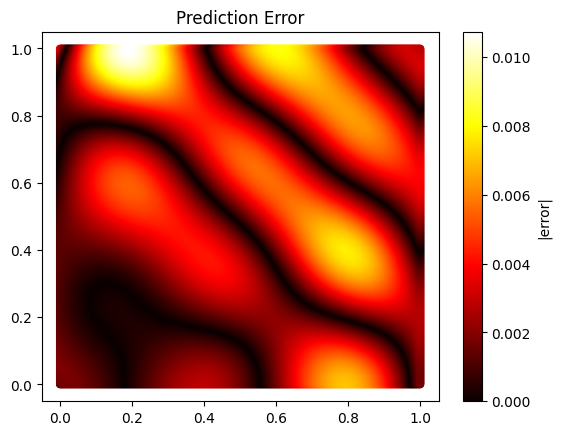

In [68]:
u_true_flat = u_true.flatten()
u_pred_flat = u_pred.flatten()
error = (u_true_flat - u_pred_flat).abs()
error_np = error.detach().numpy().flatten()
plt.scatter(X_np[:,0], X_np[:,1], c=error_np, cmap='hot', s=20)
plt.colorbar(label='|error|')
plt.title('Prediction Error')
plt.show()